# Topic 3 — Decision Trees and Random Forests in Python

Companion notebook for the theory file **`03_Decision_Trees_and_Random_Forests.tex`**.

Recall the two ideas:
- A **decision tree** plays Twenty Questions with the features, greedily choosing the split (feature + threshold) that most reduces impurity (Gini or entropy). Fully grown trees memorise noise, so we prune or cap depth.
- A **random forest** trains many deliberately-different trees (bootstrap rows + random feature subsets per split) and takes a majority vote; diverse errors cancel out. Neither method needs feature scaling.

This notebook has two parts:
1. **Part A** — a single tree and a forest on the mini bootcamp dataset, with the learned rules printed and drawn.
2. **Part B** — a real medical dataset (`kyphosis.csv`): predicting whether the kyphosis spinal condition was still present after corrective surgery, comparing a single decision tree against a random forest.

## Part A — Tree and Forest on the Bootcamp Admissions Data

### A single decision tree

In [2]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

X = np.array([[2, 45], [4, 55], [5, 60],
              [6, 62], [8, 70], [10, 85]])
y = np.array([0, 0, 0, 1, 1, 1])
feature_names = ["hours", "score"]

# max_depth limits tree size to guard against overfitting.
# Note: trees do NOT require feature scaling.
tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree.fit(X, y)

# Text view of the learned rules
print(export_text(tree, feature_names=feature_names))

# Which features mattered most?
print("Feature importances:", tree.feature_importances_)

# Predict a new applicant
print("Prediction:", tree.predict([[7, 66]]))

|--- hours <= 5.50
|   |--- class: 0
|--- hours >  5.50
|   |--- class: 1

Feature importances: [1. 0.]
Prediction: [1]


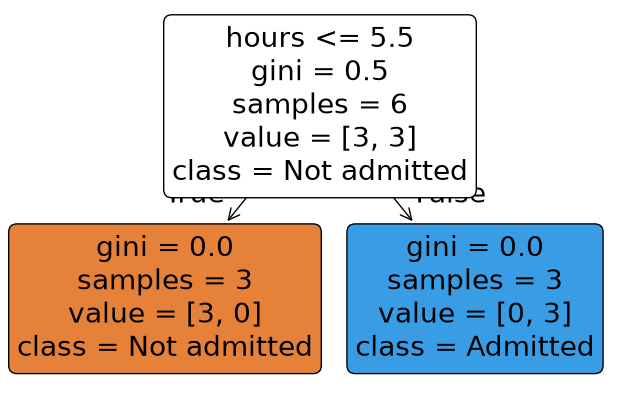

In [2]:
# Graphical view
plt.figure(figsize=(8, 5))
plot_tree(tree, feature_names=feature_names,
          class_names=["Not admitted", "Admitted"],
          filled=True, rounded=True)
plt.show()

**Interpreting the output**

- The printed rules read like plain English: study more than 5.5 hours and the tree predicts admission — exactly the by-hand information-gain example in the theory file (that split has gain = 1 bit, removing all uncertainty).
- `feature_importances_` sums to 1: here "hours" alone did all the work (1.0) and "score" was never needed (0.0).
- This transparency — being able to print the exact rules — is the decision tree's superpower.

### A random forest on the same data

In [3]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_features="sqrt",   # features considered per split
    oob_score=True,        # free validation from left-out rows
    bootstrap=True,        # enables bagging (the default)
    random_state=42
)
forest.fit(X, y)

print("OOB score          :", forest.oob_score_)
print("Feature importances:", forest.feature_importances_)
print("Prediction         :", forest.predict([[7, 66]]))
print("Vote fractions     :", forest.predict_proba([[7, 66]]))

OOB score          : 0.8333333333333334
Feature importances: [0.50769231 0.49230769]
Prediction         : [1]
Vote fractions     : [[0.09 0.91]]


**Interpreting the output**

| Output | Value | Interpretation |
|---------|------|----------------|
| **OOB Score** | 0.8333 | The model achieved approximately **83.33%** accuracy on Out-of-Bag validation samples. |
| **Feature Importances** | [0.5077, 0.4923] | Both features contribute almost equally to the prediction. |
| **Prediction** | [1] | The predicted class label is **1** (meaning depends on label encoding). |
| **Vote Fractions** | [[0.09, 0.91]] | About **91% of the trees** voted for Class 1, indicating high confidence in the prediction. |

## Part B — Real Data: The Kyphosis Dataset

### Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Get the data

The **Kyphosis dataset** is a medical dataset used to predict whether a child develops **kyphosis** after spinal surgery.

**Kyphosis** is an abnormal forward curvature of the spine (often called a "hunchback").

The goal is to predict whether kyphosis is **present** or **absent** after surgery.
---

## Dataset Overview

| Column | Description |
|----------|-------------|
| **Kyphosis** | Target variable (Present or Absent) |
| **Age** | Age of the patient in **months** at the time of surgery |
| **Number** | Number of vertebrae involved in the surgery |
| **Start** | Starting vertebra level where the surgery begins |

In [5]:
df = pd.read_csv('kyphosis.csv')
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Kyphosis  81 non-null     str  
 1   Age       81 non-null     int64
 2   Number    81 non-null     int64
 3   Start     81 non-null     int64
dtypes: int64(3), str(1)
memory usage: 2.7 KB


The columns: `Kyphosis` (whether the condition was present after the operation), `Age` of the patient in months, `Number` of vertebrae involved, and `Start` (the topmost vertebra operated on).

### EDA

We'll just check out a simple pairplot for this small dataset.

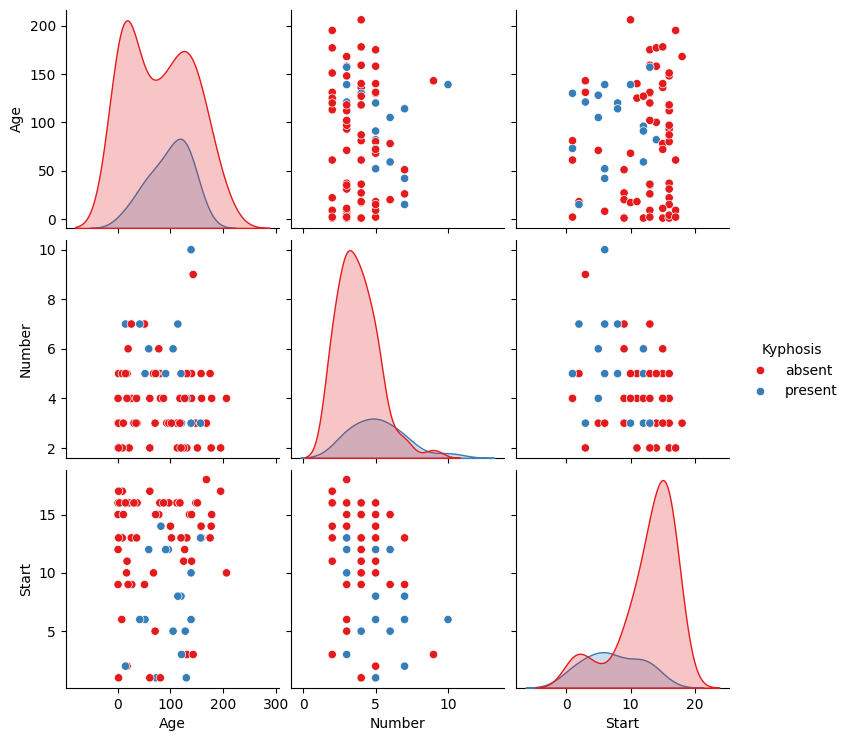

In [7]:
sns.pairplot(df, hue='Kyphosis', palette='Set1')

### Train test split

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('Kyphosis', axis=1)
y = df['Kyphosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,
                                                    random_state=42)

### Decision trees

We start by training a single decision tree.

In [7]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Prediction and evaluation

In [8]:
predictions = dtree.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[16  3]
 [ 4  2]]
              precision    recall  f1-score   support

      absent       0.80      0.84      0.82        19
     present       0.40      0.33      0.36         6

    accuracy                           0.72        25
   macro avg       0.60      0.59      0.59        25
weighted avg       0.70      0.72      0.71        25



### Tree visualization

scikit-learn has built-in visualization for decision trees via `plot_tree` (the older `export_graphviz`/`pydot` route also exists, but requires extra installs):

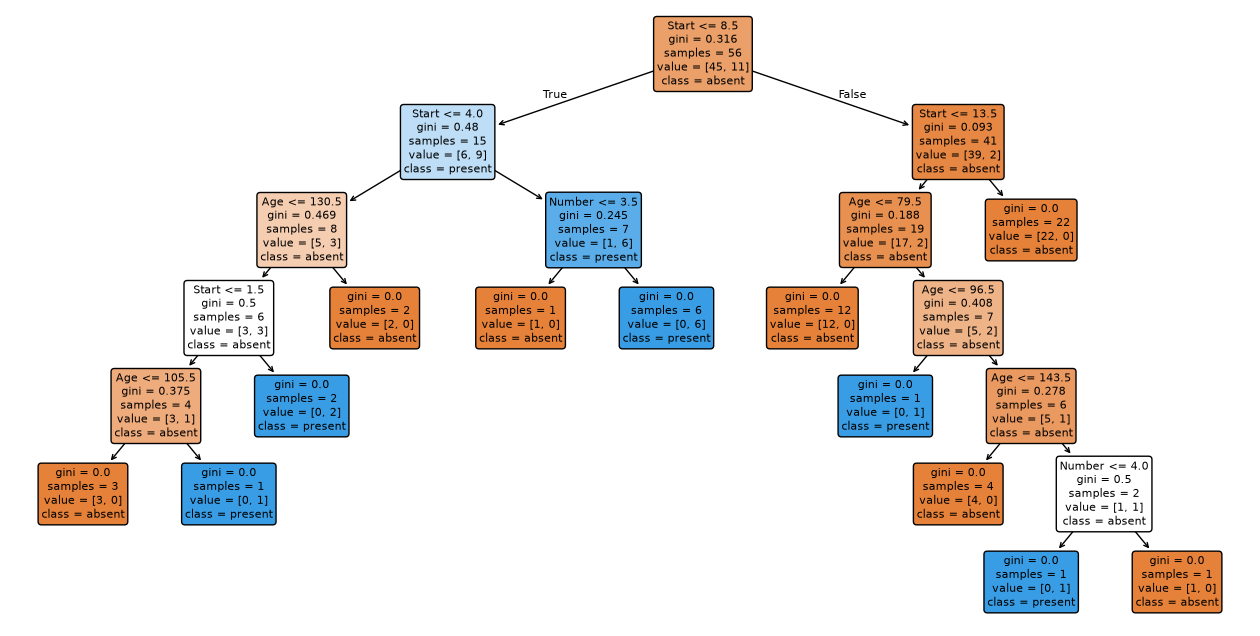

In [9]:
from sklearn.tree import plot_tree

features = list(df.columns[1:])
plt.figure(figsize=(16, 8))
plot_tree(dtree, feature_names=features,
          class_names=dtree.classes_,
          filled=True, rounded=True, fontsize=8)
plt.show()

Notice how deep the unrestricted tree grows on only ~56 training rows — many leaves cover just one or two patients. That is the memorisation problem from the theory file.

### Random forests

Now let's compare the single decision tree to a random forest.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

rfc_pred = rfc.predict(X_test)

In [11]:
print(confusion_matrix(y_test, rfc_pred))
print(classification_report(y_test, rfc_pred))

[[19  0]
 [ 5  1]]
              precision    recall  f1-score   support

      absent       0.79      1.00      0.88        19
     present       1.00      0.17      0.29         6

    accuracy                           0.80        25
   macro avg       0.90      0.58      0.58        25
weighted avg       0.84      0.80      0.74        25



In [12]:
# The forest's built-in feature importances
for name, imp in zip(X.columns, rfc.feature_importances_):
    print(f"{name:8s}: {imp:.3f}")

Age     : 0.339
Number  : 0.222
Start   : 0.439


On such a small, imbalanced dataset (most patients are `absent`) the exact numbers wobble from split to split, but the forest is typically at least as good as the tree and much more stable — the wisdom-of-crowds effect. Also note the accuracy trap: predicting `absent` for everyone already scores about 80% here, which is why the per-class rows of the classification report matter (see Topic 4).